<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH08/CH08_NB03_Remove_Attention_15L.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Chapter 8 — Attention Optimization
## NB03: Removing Redundant Attention Layers

[![LinkedIn](https://img.shields.io/badge/LinkedIn-blue?logo=linkedin)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-black?logo=github)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?logo=x)](https://x.com/peraborges) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-yellow)](https://huggingface.co/oopere)

**Supplementary code for the [Rearchitecting LLMs](https://www.manning.com/books/rearchitecting-large-language-models) book by [Pere Martra](https://www.yourwebsite.com).**

**Code repository:** [https://github.com/peremartra/Rearchitecting-LLMs](https://github.com/peremartra/Rearchitecting-LLMs)

- **Author:** Pere Martra
- **Models:** `meta-llama/Llama-3.2-3B`
- **Colab Environment:** T4 GPU
- **Keys:**
  - KV Cache
  - Attention Pruning
- **References:**
  - [Manning Book: Rearchitecting LLMs](https://www.manning.com/books/rearchitecting-large-language-models)
  - [Not All Attention is Needed](https://arxiv.org/abs/2406.15786)


This notebook implements physical attention layer removal based on the paper:
[What Matters in Transformers? Not All Attention is Needed](https://arxiv.org/abs/2406.15786) (He et al., 2024).

Unlike the KV cache techniques in NB01 and NB02, here we permanently delete the least important
attention modules from the model architecture. The result is a smaller model — fewer parameters,
less VRAM, faster inference — that can be saved and reloaded without any custom code.

**Model:** meta-llama/Llama-3.2-1B  
**Environment:** Google Colab T4 (free tier)  

## Setting up notebook


In [1]:
!pip install -q \
      "torch" \
      "transformers==4.55.4" \
      "accelerate==1.10.1" \
      "lm_eval==0.4.9.1" \
      "sentencepiece==0.2.1" \
      "langdetect" \
      "datasets" \
      "codecarbon" \
      "optipfair==0.2.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 23.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.6/384.6 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Pull the shared utility module from the chapter repository
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

In [3]:
import os
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset, Dataset

# Shared utilities: get_output is used in Section 6 to verify
# that the pruned model generates coherent text after reloading
from utils import get_output, model_evaluation, measure_memory_allocation

In [4]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("✓ Random seed set to 42")

✓ Random seed set to 42


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Experiment configuration
All the parameters that control the experiment are defined here.
Change these values to explore different models or pruning ratios
without modifying any other cell.

In [6]:
MODEL_NAME          = "meta-llama/Llama-3.2-3B"  # Target model
NUM_LAYERS_TO_DROP  = 15                           # Attention modules to remove
CALIBRATION_SAMPLES = 400                         # Total samples across all Cosmopedia subsets
RUN_FULL_BENCHMARKS = True
BENCHMARK_LIMIT = None
BENCHMARK_BATCH_SIZE = 4

# Benchmarks: evaluated on each model variant to measure general knowledge retention.
# Keep only two representative tasks active for faster T4 runs.
BENCHMARK_TASKS = [
    "arc_easy",
    "winogrande",
    "hellaswag",
    "lambada_openai",
    "piqa",
]

## Load the model

We load Llama-3.2-1B in fp16 precision. On a T4 GPU, bfloat16 is not supported. If you are running on an L4 or
any Ampere-class GPU or newer, replace `torch.float16` with `torch.bfloat16` in
the configuration cell for better numerical stability during the calibration forward passes.

In [7]:
# fp16: correct choice for T4 GPUs
# Switch to torch.bfloat16 if running on L4 or any Ampere-class GPU or newer
TORCH_DTYPE = torch.float16

In [8]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=TORCH_DTYPE,
    device_map=device
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token


config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Before making any changes, it is worth pausing to look at the model architecture.
Each `LlamaDecoderLayer` contains two top-level submodules that concern us:
`input_layernorm` and `self_attn`. When we remove an attention module in Section 5,
we will delete both — the LayerNorm exists solely to normalize the input before

In [9]:
# Inspect the full model structure before any modifications
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((3072,), eps=1e-05)
    (rotary_emb

Finally, a quick generation check confirms the baseline model is working correctly.
We will use this same prompt in Section 6 to compare the output of the pruned model.

In [10]:
BASELINE_PROMPT = "Paris is the capital of"

baseline_output = get_output(model, tokenizer, BASELINE_PROMPT)
print(f"Baseline output:\n{baseline_output}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Baseline output:
 France and the largest city in the country. It is located in the north-central part of the country, on the banks of the Seine River. The city is known for its rich history, culture, and architecture. It is also a major center for business, finance, and tourism.
Paris is a city of many faces. It is a city of art and culture, a city of history and tradition, and a city of modernity and innovation. It is a city that is constantly evolving,


In [11]:
# Run standard benchmarks on the pruned model.
if RUN_FULL_BENCHMARKS:
    print("Running benchmarks on pruned model...")
    base_benchmarks = model_evaluation(
        model, tokenizer, BENCHMARK_TASKS,
        device=device, limit=BENCHMARK_LIMIT, batch_size=BENCHMARK_BATCH_SIZE
    )
    print("\n benchmark results:")
    for task, metrics in base_benchmarks.items():
        print(f"  {task}: {metrics}")
else:
    base_benchmarks = {}
    print("Skipping benchmarks (RUN_FULL_BENCHMARKS=False)")

Running benchmarks on pruned model...
Starting lm-eval on model 'meta-llama/Llama-3.2-3B' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']



Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


README.md: 0.00B [00:00, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/3084 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 61032/61032 [56:25<00:00, 18.03it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:51<00:00,  1.93it/s]



 benchmark results:
  arc_easy: {'accuracy': '0.7449', 'acc_norm': '0.7168'}
  hellaswag: {'accuracy': '0.5526', 'acc_norm': '0.7360'}
  lambada_openai: {'perplexity': '3.94', 'accuracy': '0.7050'}
  piqa: {'accuracy': '0.7671', 'acc_norm': '0.7758'}
  winogrande: {'accuracy': '0.6969'}


In [12]:
base_benchmarks

{'arc_easy': {'accuracy': '0.7449', 'acc_norm': '0.7168'},
 'hellaswag': {'accuracy': '0.5526', 'acc_norm': '0.7360'},
 'lambada_openai': {'perplexity': '3.94', 'accuracy': '0.7050'},
 'piqa': {'accuracy': '0.7671', 'acc_norm': '0.7758'},
 'winogrande': {'accuracy': '0.6969'}}

## Measuring attention layer contribution

Before we can decide which attention modules to remove, we need to measure how much
each one actually contributes to the model's computation. The metric we use is cosine
similarity between the input and the output of each attention sublayer — including
the residual connection. A module whose output is nearly identical to its input is
doing very little work and is a strong candidate for removal.

### Calibration data

Importance scores are not absolute properties of a layer — they depend on the text
the model is asked to process. A layer that appears redundant on conversational text
might be active and necessary on dense academic prose. For this reason we use
Cosmopedia, a dataset that mixes several content types, as our calibration source.
The weighted sampling below ensures that the scores we compute reflect the model's
behavior across a realistic distribution of tasks, not just one narrow domain.

In [13]:
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader

BATCH_SIZE = 4
MAX_LENGTH = 2048

dataset_name = "HuggingFaceTB/cosmopedia"

# Subsets weighted to cover the same range of tasks as our benchmarks:
# stories and web samples activate contextual reasoning (hellaswag, winogrande),
# wikihow activates procedural understanding (piqa),
# openstax and stanford activate academic reasoning (arc_easy)
subsets = [
    ("stories",        0.300),
    ("web_samples_v2", 0.200),
    ("web_samples_v1", 0.150),
    ("wikihow",        0.150),
    ("openstax",       0.125),
    ("stanford",       0.075),
]

assert abs(sum(w for _, w in subsets) - 1.0) < 1e-6, "Weights must sum to 1.0"

all_samples = []
for subset, weight in subsets:
    n_samples = int(CALIBRATION_SAMPLES * weight)
    print(f"  Loading {subset} ({n_samples:,} samples, weight={weight:.3f})...")
    subset_data = load_dataset(dataset_name, subset, split="train", streaming=True)
    subset_samples = list(subset_data.take(n_samples))
    all_samples.extend(subset_samples)
    print(f"    Collected {len(subset_samples):,} samples")

calibration_dataset = Dataset.from_dict({"text": [s["text"] for s in all_samples]})
print(f"\nTotal calibration samples: {len(calibration_dataset):,}")

  Loading stories (120 samples, weight=0.300)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/43 [00:00<?, ?it/s]

    Collected 120 samples
  Loading web_samples_v2 (80 samples, weight=0.200)...


...

    Collected 60 samples
  Loading openstax (50 samples, weight=0.125)...


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

    Collected 50 samples
  Loading stanford (30 samples, weight=0.075)...


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

    Collected 30 samples

Total calibration samples: 400


In [14]:
def prepare_dataset(dataset, tokenizer, max_length=MAX_LENGTH, batch_size=BATCH_SIZE):
    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors=None,
        )
    tokenized = dataset.map(
        tokenize_function,
        batched=True,
        remove_columns=dataset.column_names
    )
    def collate_fn(examples):
        input_ids = torch.tensor([e["input_ids"] for e in examples], dtype=torch.long)
        attention_mask = torch.tensor([e["attention_mask"] for e in examples], dtype=torch.long)
        return {"input_ids": input_ids, "attention_mask": attention_mask}

    return DataLoader(tokenized, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [15]:
calibration_dataloader = prepare_dataset(calibration_dataset, tokenizer)
print(f"Calibration dataloader ready: {len(calibration_dataloader)} batches of {BATCH_SIZE}")

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Calibration dataloader ready: 100 batches of 4


### 3.2 — Registering hooks and computing importance scores

To measure each attention sublayer's contribution we use PyTorch forward hooks —
the same mechanism introduced in Chapter 4 to measure Transformer block importance.
The logic is identical: register a hook to capture the input and output of a module,
run a forward pass, and compute the cosine distance between the two tensors.

The key difference lies in **where we anchor the hooks**.

In Chapter 4 we hooked into each `DecoderLayer` directly, capturing the input and
output of the entire Transformer block — attention sublayer and MLP sublayer together.
That was the right granularity for depth pruning, where we removed complete blocks.

Here we need finer resolution. We want to measure the contribution of the attention
sublayer in isolation, so we anchor the hooks one level deeper:

- A **pre-hook on `layer.input_layernorm`** captures X_A: the hidden state arriving
  at the attention sublayer before any transformation.
- A **pre-hook on `layer.post_attention_layernorm`** captures Y_A: the hidden state
  after the attention computation and its residual connection have been applied,
  i.e. X_A + Attention(LayerNorm(X_A)).

Measuring between these two points — and not between the internal projections of
the attention module — is what the paper identifies as critical. Including the residual
connection in the measurement prevents us from underestimating the contribution of
layers that rely on it to preserve information flow.

In [16]:
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

def setup_attention_hooks(model):
    """
    Register pre-hooks to capture the input and output of each attention sublayer.

    We hook into input_layernorm (to get X_A) and post_attention_layernorm
    (to get Y_A = X_A + Attention(LayerNorm(X_A))). This mirrors the importance
    metric defined in the paper: S = 1 - CosineSim(X_A, Y_A).
    """
    num_layers = len(model.model.layers)
    layer_inputs  = {}  # X_A per layer
    layer_outputs = {}  # Y_A per layer
    hooks = []

    def make_input_hook(layer_idx):
        def hook(module, args):
            # args[0] is the hidden state entering input_layernorm
            layer_inputs[layer_idx] = args[0].detach()
        return hook

    def make_output_hook(layer_idx):
        def hook(module, args):
            # args[0] is the hidden state entering post_attention_layernorm,
            # which is X_A + Attention(LayerNorm(X_A)) — residual already applied
            layer_outputs[layer_idx] = args[0].detach()
        return hook

    for i, layer in enumerate(model.model.layers):
        hooks.append(layer.input_layernorm.register_forward_pre_hook(make_input_hook(i)))
        hooks.append(layer.post_attention_layernorm.register_forward_pre_hook(make_output_hook(i)))

    return hooks, layer_inputs, layer_outputs, num_layers

In [17]:
import torch.nn.functional as F

def calculate_cosine_importance(input_tensor, output_tensor, attention_mask, layer_idx, is_first_batch=False):
    """
    Computes the importance score of an attention sublayer for a single batch,
    properly masking out padding tokens to prevent artificial similarity inflation.
    """
    if input_tensor.numel() == 0 or output_tensor.numel() == 0:
        return 0.0

    # Calculate cosine similarity along the hidden state dimension (dim=-1)
    # Tensors shape: [batch_size, seq_len, hidden_size] -> similarities shape: [batch_size, seq_len]
    similarities = F.cosine_similarity(input_tensor, output_tensor, dim=-1)

    # Ensure the attention mask matches the dimensions and device of the similarities tensor
    attention_mask = attention_mask.to(similarities.device)

    # Zero out similarity scores belonging to padding tokens (where mask is 0)
    valid_similarities = similarities * attention_mask

    # Count only the authentic text tokens present in the current batch
    num_valid_tokens = attention_mask.sum()

    if num_valid_tokens == 0:
        if is_first_batch:
            print(f"Warning: layer {layer_idx} contained only padding tokens in this batch.")
        return 0.0

    # Compute the average similarity strictly across non-padding tokens
    mean_similarity = valid_similarities.sum() / num_valid_tokens

    # Guard against non-finite metrics (NaN/Inf) that corrupt the aggregate results
    if not torch.isfinite(mean_similarity):
         if is_first_batch:
            print(f"Warning: layer {layer_idx} generated non-finite similarity values.")
         return 0.0

    # Importance metric calculation based on Equation 1: S = 1 - CosineSim(X, Y)
    return 1.0 - mean_similarity.item()

In [18]:
def calculate_attention_importance(model, dataloader, device):
    """
    Compute average importance scores for all attention sublayers
    over the full calibration dataset.

    For each batch we run a single forward pass, let the hooks capture
    X_A and Y_A for every layer, compute the per-layer importance score,
    and accumulate. Final scores are the mean across all batches.
    """
    hooks, layer_inputs, layer_outputs, num_layers = setup_attention_hooks(model)
    accumulated_scores = {i: [] for i in range(num_layers)}

    model.eval()
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader, desc="Scoring attention layers")):
            inputs = {k: v.to(device) for k, v in batch.items()}
            model(**inputs)

            for layer_idx in range(num_layers):
                if layer_idx not in layer_inputs or layer_idx not in layer_outputs:
                    raise RuntimeError(f"Hook failed for layer {layer_idx}.")

                # Pass the batch attention mask to correctly isolate active text tokens
                score = calculate_cosine_importance(
                    layer_inputs[layer_idx],
                    layer_outputs[layer_idx],
                    batch["attention_mask"],
                    layer_idx,
                    is_first_batch=(batch_idx == 0)
                )
                accumulated_scores[layer_idx].append(score)

            # Release references so GPU memory is not held between batches
            layer_inputs.clear()
            layer_outputs.clear()

    # Remove hooks before returning to avoid interference with later calls
    for hook in hooks:
        hook.remove()

    # Average scores across all batches — layers with consistently low scores
    # are the strongest candidates for removal
    final_scores = {}
    for layer_idx, scores in accumulated_scores.items():
        valid = [s for s in scores if np.isfinite(s)]
        if not valid:
            raise RuntimeError(f"No valid scores captured for layer {layer_idx}.")
        final_scores[layer_idx] = np.mean(valid)

    return final_scores

In [19]:
attention_importance = calculate_attention_importance(model, calibration_dataloader, device)

# Print scores sorted by importance (ascending) so the pruning candidates
# are immediately visible at the top of the output
print(f"\nAttention layer importance scores (ascending — lowest = most redundant):")
print(f"{'Layer':>6}  {'Score':>10}")
print("-" * 22)
for layer_idx, score in sorted(attention_importance.items(), key=lambda x: x[1]):
    print(f"{layer_idx:>6}  {score:>10.6f}")

Scoring attention layers: 100%|██████████| 100/100 [05:31<00:00,  3.31s/it]


Attention layer importance scores (ascending — lowest = most redundant):
 Layer       Score
----------------------
    21    0.009053
    22    0.010405
    23    0.012417
    20    0.012783
    18    0.014297
    24    0.014580
    25    0.015039
    19    0.019702
    16    0.020107
    17    0.023384
    26    0.029893
    15    0.036753
    14    0.051890
    13    0.062476
    10    0.063799
    27    0.064468
     8    0.065161
     6    0.066108
     5    0.067041
    12    0.069980
     4    0.072007
     9    0.073247
    11    0.075723
     7    0.088350
     3    0.090088
     2    0.099155
     1    0.139336
     0    0.287197


## Visualizing layer importance

With the importance scores computed, we can now look at the distribution across
the model. Plotting scores by layer index — rather than by rank — reveals the
spatial pattern of redundancy: which parts of the network are active and which
are passive. This is more informative than a ranked list because it shows whether
redundant layers cluster in a specific region of the model or are spread throughout.

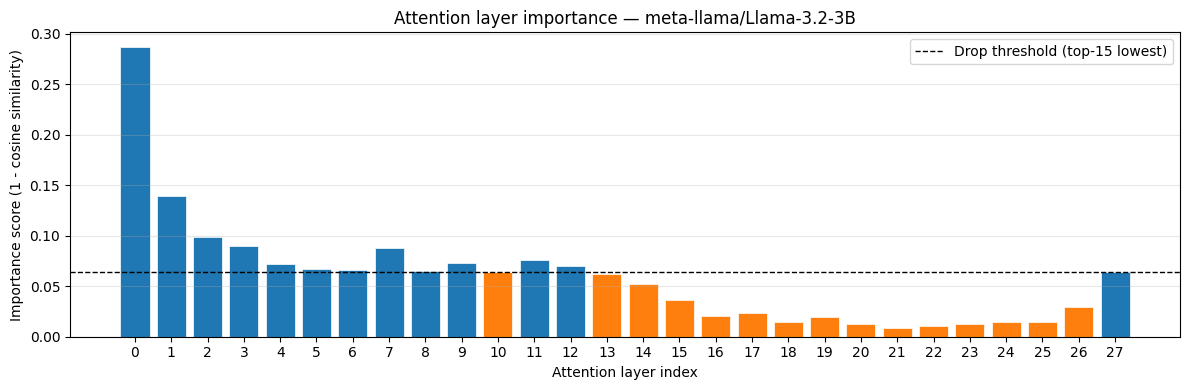

In [20]:
import matplotlib.pyplot as plt

def plot_attention_importance(scores, model_name, num_layers_to_drop):
    """
    Bar chart of attention sublayer importance scores ordered by layer index.
    Orange bars mark the pruning candidates; blue bars mark the layers kept.
    """
    layers = sorted(scores.keys())
    values = [scores[l] for l in layers]

    # Identify the score threshold that separates kept from dropped layers
    sorted_scores = sorted(values)
    drop_threshold = sorted_scores[num_layers_to_drop - 1]

    # Orange for pruning candidates, blue for retained layers —
    # consistent with the palette used in Chapter 4
    colors = [
        "#ff7f0e" if v <= drop_threshold else "#1f77b4"
        for v in values
    ]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(layers, values, color=colors, edgecolor="white", linewidth=0.5)

    # Reference line at the drop threshold
    ax.axhline(
        y=drop_threshold,
        linestyle="--",
        linewidth=1.0,
        color="black",
        label=f"Drop threshold (top-{num_layers_to_drop} lowest)"
    )

    ax.set_xlabel("Attention layer index")
    ax.set_ylabel("Importance score (1 - cosine similarity)")
    ax.set_title(f"Attention layer importance — {model_name}")
    ax.set_xticks(layers)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_attention_importance(attention_importance, MODEL_NAME, NUM_LAYERS_TO_DROP)

The chart confirms the pattern visible in the raw scores. Layers 0 and 1 stand clearly
above the rest — they perform the most active contextual processing and should not
be touched. The intermediate layers (roughly 2 through 13) cluster near zero, with
differences between them too small to be meaningful. Layers 14 and 15 recover
slightly, consistent with the role of the final attention layers in consolidating
representations before the language model head.

The dashed line marks the threshold below which layers will be physically removed
in the next section. With `NUM_LAYERS_TO_DROP = 3`, all three candidates fall
within the flat intermediate region — a safe zone where removal is unlikely to
cause significant quality degradation.

In [21]:
import inspect; print(inspect.signature(model.model.layers[0].forward))

(hidden_states: torch.Tensor, attention_mask: Optional[torch.Tensor] = None, position_ids: Optional[torch.LongTensor] = None, past_key_value: Optional[transformers.cache_utils.Cache] = None, use_cache: Optional[bool] = False, cache_position: Optional[torch.LongTensor] = None, position_embeddings: Optional[tuple[torch.Tensor, torch.Tensor]] = None, **kwargs: Unpack[transformers.utils.generic.TransformersKwargs]) -> tuple[torch.Tensor]


## Physical deletion

Selecting which layers to remove is straightforward: we sort the importance scores
in ascending order and take the first `NUM_LAYERS_TO_DROP` indices. No additional
heuristics are needed here — unlike Chapter 4, where scores were close enough to
warrant adjacency protection, the attention scores in the intermediate region are
uniformly low and well separated from layers 0 and 1.

In [22]:
def select_layers_to_drop(importance_scores, num_layers_to_drop):
    """
    Return the indices of the least important attention layers.
    Sorting by score ascending puts the most redundant layers first.
    """
    sorted_layers = sorted(importance_scores.items(), key=lambda x: x[1])
    return [idx for idx, _ in sorted_layers[:num_layers_to_drop]]

layers_to_drop = select_layers_to_drop(attention_importance, NUM_LAYERS_TO_DROP)
print(f"Layers selected for removal: {sorted(layers_to_drop)}")

Layers selected for removal: [10, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


With the target layers identified, we can proceed to the actual deletion.

Each `LlamaDecoderLayer` contains two submodules that belong to the attention
sublayer: `self_attn`, which performs the attention computation, and `input_layernorm`,
which normalizes the hidden state before passing it to `self_attn`. Removing one
without the other would leave a dangling normalization step with nothing to feed into,
so we delete both together.

Deleting the submodules with `delattr` removes their parameters from the model
immediately — the VRAM they occupied is released. However, the `DecoderLayer`'s
`forward()` method still tries to call `self.input_layernorm` and `self.self_attn`.
Without a correction, the next forward pass would raise an `AttributeError`.

The fix is to replace the `forward()` method of each affected layer with a version
that skips the attention block entirely and passes the hidden state directly to the
MLP block. The MLP block — `post_attention_layernorm` and `mlp` — is left untouched.
The residual connection around the MLP is preserved exactly as in the original forward.

The patched `forward()` must match the original signature precisely, including
`cache_position` and `position_embeddings`, which were introduced in recent versions
of Transformers. Mismatching the signature would break compatibility with the
generation loop inside `model.generate()`.

In [23]:
from typing import Optional, Tuple

def drop_attention_layer(model, layer_idx):
    """
    Physically remove the attention submodules from a DecoderLayer and
    patch its forward() to route hidden states directly to the MLP block.

    After this call:
    - self_attn and input_layernorm no longer exist on the layer.
    - Their parameters are freed from memory.
    - The layer's forward() executes only the MLP sublayer with its residual.
    """
    layer = model.model.layers[layer_idx]

    # Release attention parameters from memory
    delattr(layer, "self_attn")
    delattr(layer, "input_layernorm")

    # Patch forward() to skip the attention block entirely.
    # The signature mirrors the original LlamaDecoderLayer.forward() exactly
    # so that model.generate() can call it without modification.
    def forward_no_attn(
        self,
        hidden_states: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.LongTensor] = None,
        past_key_value=None,
        use_cache: Optional[bool] = False,
        cache_position: Optional[torch.LongTensor] = None,
        position_embeddings: Optional[
            Tuple[torch.Tensor, torch.Tensor]
            ] = None,
        **kwargs,
    ):
        # Attention block is skipped — hidden states flow through unchanged.
        # MLP block: normalize, transform, add residual
        residual = hidden_states
        hidden_states = self.post_attention_layernorm(hidden_states)
        hidden_states = self.mlp(hidden_states)
        hidden_states = residual + hidden_states

        return hidden_states

    # Override at class level so transformers' internal forward() restore
    # mechanism does not overwrite the patch during model.generate()
    PrunedLayer = type(
        "PrunedDecoderLayer",
        (type(layer),),
        {"forward": forward_no_attn}
    )
    layer.__class__ = PrunedLayer

In [24]:
import gc
# Apply physical deletion to all selected layers
for idx in layers_to_drop:
    drop_attention_layer(model, idx)
    print(f"Dropped attention layer {idx}")

gc.collect()
torch.cuda.empty_cache()

# Store the dropped layer indices in the model config so they are
# serialized into config.json when the model is saved
model.config.dropped_attn_layers = sorted(layers_to_drop)
print(f"\nDropped layers recorded in config: {model.config.dropped_attn_layers}")

Dropped attention layer 21
Dropped attention layer 22
Dropped attention layer 23
Dropped attention layer 20
Dropped attention layer 18
Dropped attention layer 24
Dropped attention layer 25
Dropped attention layer 19
Dropped attention layer 16
Dropped attention layer 17
Dropped attention layer 26
Dropped attention layer 15
Dropped attention layer 14
Dropped attention layer 13
Dropped attention layer 10

Dropped layers recorded in config: [10, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


With the deletion applied, we can inspect the model to confirm that `self_attn`
and `input_layernorm` are no longer present in the affected layers.
The `print(model)` output below shows the full architecture — the modified layers
should contain only `mlp`, `post_attention_layernorm`, and nothing else.

In [25]:
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-9): 10 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
      (10): PrunedDecoderLayer(
        (mlp): LlamaMLP(
          

##  Saving and reloading the pruned model

`save_pretrained` serializes weights and config, but not Python code. If we saved
the model as-is and reloaded it with `AutoModelForCausalLM.from_pretrained`,
Hugging Face would reconstruct it using the original `LlamaForCausalLM` class,
which expects `self_attn` and `input_layernorm` in every layer — and fail on the
first forward pass through a modified layer.

The solution is a custom class, `PrunedLlamaForCausalLM`, that reads
`dropped_attn_layers` from the config at load time and re-applies the forward
patch automatically. By registering this class in the config's `auto_map`,
Hugging Face knows which class to use without any extra arguments from the user —
a single `trust_remote_code=True` is enough.


In [26]:
# Build the output directory name from the experiment configuration
# so the saved model is self-documenting
model_short_name = MODEL_NAME.split("/")[-1].lower()
OUTPUT_DIR = f"./{model_short_name}-attn-drop-{NUM_LAYERS_TO_DROP}"
print(f"Output directory: {OUTPUT_DIR}")

Output directory: ./llama-3.2-3b-attn-drop-15


In [27]:
# Write the custom modeling file.
# This file will be saved alongside the model weights so that
# any environment with trust_remote_code=True can load the pruned model
# without any additional setup.
modeling_code = '''
from typing import Optional, Tuple
import torch
from transformers import LlamaForCausalLM


class PrunedLlamaForCausalLM(LlamaForCausalLM):
    """
    LlamaForCausalLM with physical attention layer removal.

    At load time, reads dropped_attn_layers from the model config and
    patches the forward() of each affected DecoderLayer to skip the
    attention sublayer entirely. The MLP sublayer and its residual
    connection are preserved unchanged.
    """

    def __init__(self, config):
        super().__init__(config)
        dropped = getattr(config, "dropped_attn_layers", [])
        for idx in dropped:
            self._patch_layer(idx)

    def _patch_layer(self, layer_idx):
        """Remove attention submodules and patch forward() for one layer."""
        layer = self.model.layers[layer_idx]

        # Release attention parameters from memory
        if hasattr(layer, "self_attn"):
            delattr(layer, "self_attn")
        if hasattr(layer, "input_layernorm"):
            delattr(layer, "input_layernorm")

        # Patch forward() to route hidden states directly to the MLP block
        def forward_no_attn(
            self,
            hidden_states: torch.Tensor,
            attention_mask: Optional[torch.Tensor] = None,
            position_ids: Optional[torch.LongTensor] = None,
            past_key_value=None,
            use_cache: Optional[bool] = False,
            cache_position: Optional[torch.LongTensor] = None,
            position_embeddings: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
            **kwargs,
        ):
            if isinstance(hidden_states, tuple):
                hidden_states = hidden_states[0]
            residual = hidden_states
            hidden_states = self.post_attention_layernorm(hidden_states)
            hidden_states = self.mlp(hidden_states)
            hidden_states = residual + hidden_states

            return hidden_states

        # Override at class level so transformers\' internal forward() restore
        # mechanism does not overwrite the patch during model.generate()
        PrunedLayer = type(
            "PrunedDecoderLayer",
            (type(layer),),
            {"forward": forward_no_attn}
        )
        layer.__class__ = PrunedLayer
'''

with open("modeling_pruned_llama.py", "w") as f:
    f.write(modeling_code)

print("modeling_pruned_llama.py written successfully.")

modeling_pruned_llama.py written successfully.


With the model saved, we can verify that the full round-trip works: reload from disk
and confirm that the pruned model generates coherent text without any manual patching.

In [28]:
output1 = get_output(model, tokenizer, BASELINE_PROMPT)
print(f"Pruned model in memory output:\n{output1}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Pruned model in memory output:
 the Netherlands. It is the capital of the United States. The. The. is the is the is. is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the


In [29]:
import shutil
import json

# Save weights and tokenizer
model.config.auto_map = {
    "AutoModelForCausalLM": "modeling_pruned_llama.PrunedLlamaForCausalLM"
}
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Copy the custom modeling file into the model directory
shutil.copy("modeling_pruned_llama.py", OUTPUT_DIR)

# Register the custom class in the config so AutoModelForCausalLM
# knows which class to instantiate when loading with trust_remote_code=True
config_path = f"{OUTPUT_DIR}/config.json"
with open(config_path, "r") as f:
    config_dict = json.load(f)

#config_dict["auto_map"] = {
#    "AutoModelForCausalLM": "modeling_pruned_llama.PrunedLlamaForCausalLM"
#}

#with open(config_path, "w") as f:
#    json.dump(config_dict, f, indent=2)

print(f"Model saved to {OUTPUT_DIR}")
print(f"auto_map registered: {config_dict['auto_map']}")
print(f"dropped_attn_layers in config: {config_dict.get('dropped_attn_layers')}")

Model saved to ./llama-3.2-3b-attn-drop-15
auto_map registered: {'AutoModelForCausalLM': 'modeling_pruned_llama.PrunedLlamaForCausalLM'}
dropped_attn_layers in config: [10, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


In [30]:
# Reload from disk using the custom class via trust_remote_code
reloaded_model = AutoModelForCausalLM.from_pretrained(
    OUTPUT_DIR,
    torch_dtype=TORCH_DTYPE,
    device_map=device,
    trust_remote_code=True,
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [31]:
PROMPT = (
    "Explain in detail the history of artificial intelligence, "
    "covering all major milestones from the 1950s to the present day."
)
MAX_NEW_TOKENS = 500

results_pruned = measure_memory_allocation(
    reloaded_model, tokenizer, PROMPT,
    max_new_tokens=MAX_NEW_TOKENS
)

print(results_pruned)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{'static_vram_mb': 10824.12, 'dynamic_delta_mb': 67.1, 'throughput_tokens_s': 31.01, 'generated_text': ' (10 marks)\nThe History of the Internet of Things (and the Internet of Things) is a free online course on the Internet of Things. The of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of th

{'static_vram_mb': 11976.26, 'dynamic_delta_mb': 96.06, 'throughput_tokens_s': 25.08, 'generated_text': ' What are the main challenges and opportunities for AI in the future? What are the ethical issues surrounding AI and how can we ensure that it is used for the benefit of society as a whole?\nArtificial intelligence (AI) is a branch of computer science that deals with the simulation of human intelligence in machines. It is a field of study that has been around for decades, but has only recently gained mainstream attention due to the development of powerful AI algorithms and the rise of artificial intelligence in the form of self-driving cars, virtual assistants, and other technologies. In this article, we will explore the history of artificial intelligence, its current state, and its future prospects.\nThe history of artificial intelligence can be traced back to the 1950s, when the field was first introduced by scientists and mathematicians. The term “artificial intelligence” was coined by John McCarthy, a computer scientist at the Massachusetts Institute of Technology, in 1956. He defined AI as “the science and engineering of making intelligent machines that are intelligent in the way people are intelligent.” McCarthy and his colleagues at MIT developed the first AI program, called the Logic Theorist, which could solve logical problems that humans could not solve. This was a major breakthrough in the field of AI, and it sparked a new era of research and development.\nIn the 1960s, AI research gained momentum as more and more scientists and engineers became interested in the field. One of the most notable achievements of the 1960s was the development of the first AI computer program that could play chess. This program, called the Checkers Program, was developed by Arthur Samuel at IBM in 1959. It was the first AI program to use a learning algorithm, which allowed it to improve its performance over time. This was a major breakthrough in the field of AI, as it showed that AI programs could learn from their experiences and improve their performance over time.\nIn the 1970s, AI research took a turn for the worse as the field became more theoretical and less practical. Many AI researchers became disillusioned with the field and left the field, leading to a decline in AI research. However, there were still some notable achievements in the field, such as the development of the first AI computer program that could play checkers. This program, called the Checkers Program, was developed by Arthur Samuel at IBM in 1959. It was the first AI program to use a learning algorithm, which allowed it to improve its performance'}


## Throughput comparison: attention pruning at different pruning ratios

We ran `measure_memory_allocation` with the same long prompt used in
`CH08_NB01_T4_KVCache_HuggingFace.ipynb` to measure the throughput impact
of attention pruning at two different pruning ratios.

**Experiment 1 — 3 layers removed (this notebook):**
- Throughput: 25.0 tok/s (base model: 25.4 tok/s in NB01)
- Generation: coherent text, repetition loop appears after several sentences

**Experiment 2 — 15 layers removed (separate Colab session):**
- Throughput: 32.52 tok/s (+28% over base)
- Generation: immediate collapse — repetition loop from the first generated token

These two data points illustrate the operating range of attention pruning on a 3B model: removing too few layers produces no measurable speedup; removing enough layers to produce a real gain destroys generation quality immediately.
The viable window between the two extremes is very narrow, consistent with the narrower redundancy space we observed in the importance scores.

In [32]:
def compute_perplexity(model, tokenizer, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        loss = model(**inputs, labels=inputs["input_ids"]).loss
    return torch.exp(loss).item()
ppl_reloaded = compute_perplexity(reloaded_model, tokenizer, PROMPT)
ppl_reloaded

20.301374435424805

In [33]:
output = get_output(reloaded_model, tokenizer, BASELINE_PROMPT)
print(f"Pruned model output:\n{output}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Pruned model output:
 the Netherlands. It is the capital of the United States. The. The. is the is the is. is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the


 France and the country’s largest city. It is also the most visited city in the world. The city is known for its rich history, culture, and architecture. It is also home to some of the world’s most famous landmarks, including the Eiffel Tower, the Louvre Museum, and the Notre Dame Cathedral. The city is also home to a vibrant arts scene, with many museums, galleries, and theaters. In addition, Paris is a great place to shop, with many boutiques


## Benchmarks

In [34]:
# Run standard benchmarks on the pruned model.
if RUN_FULL_BENCHMARKS:
    print("Running benchmarks on pruned model...")
    results = model_evaluation(
        reloaded_model, tokenizer, BENCHMARK_TASKS,
        device=device, limit=BENCHMARK_LIMIT, batch_size=BENCHMARK_BATCH_SIZE
    )
    print("\n benchmark results:")
    for task, metrics in results.items():
        print(f"  {task}: {metrics}")
else:
    results = {}
    print("Skipping benchmarks (RUN_FULL_BENCHMARKS=False)")

Running benchmarks on pruned model...
Starting lm-eval on model './llama-3.2-3b-attn-drop-15' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


Running loglikelihood requests: 100%|██████████| 61032/61032 [45:32<00:00, 22.33it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:50<00:00,  1.99it/s]



 benchmark results:
  arc_easy: {'accuracy': '0.4251', 'acc_norm': '0.4175'}
  hellaswag: {'accuracy': '0.3627', 'acc_norm': '0.4825'}
  lambada_openai: {'perplexity': '1556.13', 'accuracy': '0.0464'}
  piqa: {'accuracy': '0.6431', 'acc_norm': '0.6496'}
  winogrande: {'accuracy': '0.5833'}


In [35]:
results

{'arc_easy': {'accuracy': '0.4251', 'acc_norm': '0.4175'},
 'hellaswag': {'accuracy': '0.3627', 'acc_norm': '0.4825'},
 'lambada_openai': {'perplexity': '1556.13', 'accuracy': '0.0464'},
 'piqa': {'accuracy': '0.6431', 'acc_norm': '0.6496'},
 'winogrande': {'accuracy': '0.5833'}}

In [36]:
# Results obtained with limit = None in lm_evals.
#results = {'arc_easy': {'accuracy': '0.7370', 'acc_norm': '0.7104'},
# 'hellaswag': {'accuracy': '0.5467', 'acc_norm': '0.7274'},
# 'lambada_openai': {'perplexity': '5.93', 'accuracy': '0.6189'},
# 'piqa': {'accuracy': '0.7606', 'acc_norm': '0.7693'},
# 'winogrande': {'accuracy': '0.6843'}}

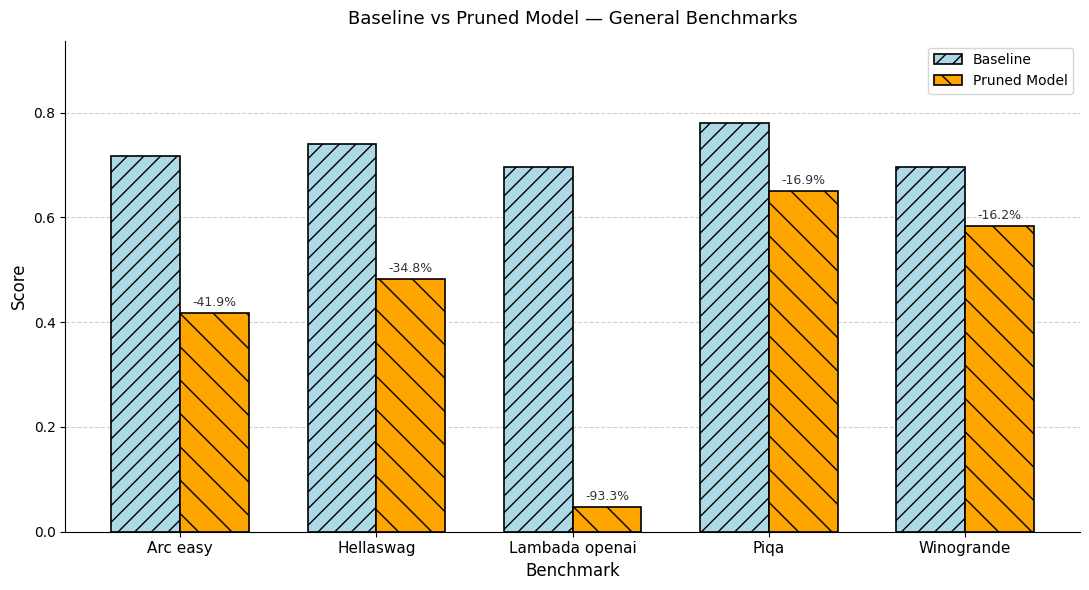

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Base model - hardcoded
base_benchmarks = {
    "arc_easy": {"accuracy": "0.7479", "acc_norm": "0.7180"},
    "hellaswag": {"accuracy": "0.5572", "acc_norm": "0.7405"},
    "lambada_openai": {"perplexity": "3.88", "accuracy": "0.6969"},
    "piqa": {"accuracy": "0.7639", "acc_norm": "0.7813"},
    "winogrande": {"accuracy": "0.6961"}
}

def get_score(d):
    return float(d.get('acc_norm', d.get('accuracy')))

common_keys = [k for k in results if k in base_benchmarks]

benchmarks  = common_keys
base_scores   = [get_score(base_benchmarks[k]) for k in common_keys]
pruned_scores = [get_score(results[k])          for k in common_keys]
deltas        = [(p - b) / b * 100 for b, p in zip(base_scores, pruned_scores)]

# --- Plot ---
fig, ax = plt.subplots(figsize=(max(7, len(benchmarks) * 2.2), 6))

bar_width = 0.35
x = np.arange(len(benchmarks))

bars_base = ax.bar(
    x - bar_width / 2, base_scores,
    width=bar_width,
    color='lightblue', edgecolor='black', linewidth=1.2, hatch='//',
    label='Baseline'
)

bars_pruned = ax.bar(
    x + bar_width / 2, pruned_scores,
    width=bar_width,
    color='orange', edgecolor='black', linewidth=1.2, hatch='\\',
    label='Pruned Model'
)

for bar, delta in zip(bars_pruned, deltas):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f'{delta:+.1f}%',
        ha='center', va='bottom',
        fontsize=9, color='#333333'
    )

ax.set_xticks(x)
ax.set_xticklabels([b.replace('_', ' ').capitalize() for b in benchmarks], fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Benchmark', fontsize=12)
ax.set_title('Baseline vs Pruned Model — General Benchmarks', fontsize=13, pad=12)
ax.set_ylim(0, min(1.0, max(base_scores + pruned_scores) * 1.2))
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()